## 1. Import Libraries

In [ ]:
from pathlib import Path
import os
import re
import math
import random
import warnings
import shutil
from copy import deepcopy
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
)

warnings.filterwarnings("ignore")

## 2. Reproducibility and Configuration

In [ ]:
# Set global seed for reproducibility
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# Select GPU if available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

PROJECT_ROOT = Path("/content")
ZIP_PATH = PROJECT_ROOT / "C-NMC_Leukemia.zip"
DATA_ROOT = PROJECT_ROOT / "C-NMC_Leukemia"

IMAGE_SIZE = 128
BATCH_SIZE = 8
NUM_WORKERS = 2

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
EPOCHS = 12

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

RESNET_IMAGE_SIZE = 224
RESNET_BATCH_SIZE = 16 if torch.cuda.is_available() else 8

RESNET_HEAD_EPOCHS = 3
RESNET_FINETUNE_EPOCHS = 8

RESNET_HEAD_LR = 1e-3
RESNET_FINETUNE_HEAD_LR = 5e-4
RESNET_BACKBONE_LR = 1e-4
RESNET_WEIGHT_DECAY = 1e-4

QUICK_DEBUG_SAMPLES_PER_CLASS = None

CLASS_NAMES = ['ALL', 'HEM']
CLASS_TO_ID = {'ALL': 0, 'HEM': 1}
ID_TO_CLASS = {v: k for k, v in CLASS_TO_ID.items()}

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

# Output folders for saving models, plots, and tables
OUTPUT_DIR = PROJECT_ROOT / "outputs_cnmc"
MODEL_DIR = OUTPUT_DIR / "models"
PLOT_DIR = OUTPUT_DIR / "plots"
TABLE_DIR = OUTPUT_DIR / "tables"

for folder in [OUTPUT_DIR, MODEL_DIR, PLOT_DIR, TABLE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-8

print("Project root :", PROJECT_ROOT)
print("Dataset root :", DATA_ROOT)
print("Output dir   :", OUTPUT_DIR)

Device: cuda
Project root : /content
Dataset root : /content/C-NMC_Leukemia
Output dir   : /content/outputs_cnmc


## 3. Extract Dataset
If the dataset ZIP file exists, this cell extracts it to `/content/C-NMC_Leukemia`.

In [ ]:
if DATA_ROOT.exists():
    print("Dataset folder already exists:", DATA_ROOT)
else:
    if not ZIP_PATH.exists():
        raise FileNotFoundError(f"ZIP file not found: {ZIP_PATH}")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(DATA_ROOT)
    print("Extracted to:", DATA_ROOT)

print("Top-level contents:")
for item in sorted(DATA_ROOT.iterdir()):
    print("-", item.name)

Extracted to: /content/C-NMC_Leukemia
Top-level contents:
- fold_0
- fold_1
- fold_2


## 4. Load and Explore Dataset

The C-NMC Leukemia dataset contains two classes:
- **ALL**: Acute Lymphoblastic Leukemia
- **HEM**: Hematologically normal cells

To reduce data leakage, the code performs a **patient-wise split** whenever subject IDs can be extracted from filenames.

In [ ]:
IMAGE_EXTENSIONS = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff', '.webp'}
LABEL_ALIASES = {
    'all': 'ALL',
    'hem': 'HEM',
    'healthy': 'HEM',
    'normal': 'HEM',
    'cancer': 'ALL',
}

def normalize_tokens(text: str):
    return re.findall(r'[a-z0-9]+', text.lower())

def infer_label_from_path(path: Path):
    candidates = list(path.parts) + [path.stem]
    for item in reversed(candidates):
        tokens = normalize_tokens(str(item))
        for token in tokens:
            if token in LABEL_ALIASES:
                return LABEL_ALIASES[token]

    stem_lower = path.stem.lower()
    if stem_lower.endswith('_all') or '_all_' in stem_lower:
        return 'ALL'
    if stem_lower.endswith('_hem') or '_hem_' in stem_lower:
        return 'HEM'
    return None

# Infer class label from folder names or filename patterns
def extract_subject_id(path: Path):
    stem = path.stem
    patterns = [
        r'UID_([^_]+)_\d+_\d+_(?:all|hem)$',
        r'UID_([^_]+)_\d+_(?:all|hem)$',
        r'UID_([^_]+)_',
    ]
    for pattern in patterns:
        match = re.search(pattern, stem, flags=re.IGNORECASE)
        if match:
            return match.group(1)
    return stem

# Extract subject ID to support subject-wise splitting
def extract_fold(path: Path):
    for part in path.parts:
        match = re.search(r'fold[_-]?(\d+)', str(part), flags=re.IGNORECASE)
        if match:
            return int(match.group(1))
    return None

# Build a structured metadata table for all valid image files
def build_metadata_dataframe(root: Path) -> pd.DataFrame:
    root = Path(root)
    if not root.exists():
        raise FileNotFoundError(f"DATA_ROOT does not exist: {root}")

    image_files = sorted([p for p in root.rglob('*') if p.suffix.lower() in IMAGE_EXTENSIONS])
    if not image_files:
        raise FileNotFoundError(f"No image files were found under: {root}")

    records = []
    for filepath in image_files:
        label_name = infer_label_from_path(filepath)
        if label_name is None:
            continue

        subject_id = extract_subject_id(filepath)
        fold = extract_fold(filepath)

        records.append({
            'filepath': str(filepath),
            'label_name': label_name,
            'label_id': CLASS_TO_ID[label_name],
            'subject_id': str(subject_id),
            'fold': fold,
            'filename': filepath.name,
        })

    metadata = pd.DataFrame(records).drop_duplicates(subset=['filepath']).reset_index(drop=True)

    if metadata.empty:
        raise ValueError("Images were found, but labels could not be inferred.")

    if QUICK_DEBUG_SAMPLES_PER_CLASS is not None:
        metadata = (
            metadata.groupby('label_name', group_keys=False)
            .apply(lambda x: x.sample(min(len(x), QUICK_DEBUG_SAMPLES_PER_CLASS), random_state=SEED))
            .reset_index(drop=True)
        )

    return metadata

metadata = build_metadata_dataframe(DATA_ROOT)
metadata.to_csv(TABLE_DIR / "metadata_full.csv", index=False)

print(f"Total labeled images found: {len(metadata):,}")
print(f"Unique subjects          : {metadata['subject_id'].nunique():,}")
print("Class distribution:")
print(metadata['label_name'].value_counts())

display(metadata.head())

Total labeled images found: 10,661
Unique subjects          : 73
Class distribution:
label_name
ALL    7272
HEM    3389
Name: count, dtype: int64


,filepath,label_name,label_id,subject_id,fold,filename
0,/content/C-NMC_Leukemia/fold_0/fold_0/all/UID_...,ALL,0,11,0,UID_11_10_1_all.bmp
1,/content/C-NMC_Leukemia/fold_0/fold_0/all/UID_...,ALL,0,11,0,UID_11_11_1_all.bmp
2,/content/C-NMC_Leukemia/fold_0/fold_0/all/UID_...,ALL,0,11,0,UID_11_11_2_all.bmp
3,/content/C-NMC_Leukemia/fold_0/fold_0/all/UID_...,ALL,0,11,0,UID_11_11_3_all.bmp
4,/content/C-NMC_Leukemia/fold_0/fold_0/all/UID_...,ALL,0,11,0,UID_11_12_1_all.bmp


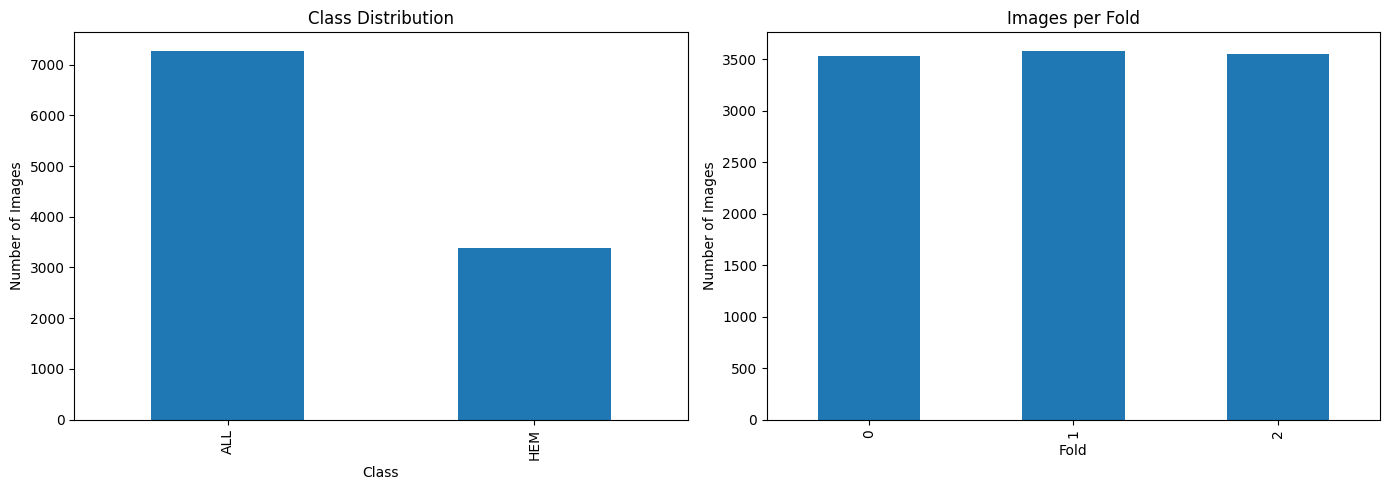

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts = metadata['label_name'].value_counts().reindex(CLASS_NAMES)
class_counts.plot(kind='bar', ax=axes[0], title='Class Distribution')
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of Images")

if metadata['fold'].notna().any():
    metadata['fold'].value_counts().sort_index().plot(kind='bar', ax=axes[1], title='Images per Fold')
    axes[1].set_xlabel("Fold")
    axes[1].set_ylabel("Number of Images")
else:
    axes[1].text(0.5, 0.5, "Fold information not found", ha='center', va='center')
    axes[1].set_title("Images per Fold")

plt.tight_layout()
plt.show()

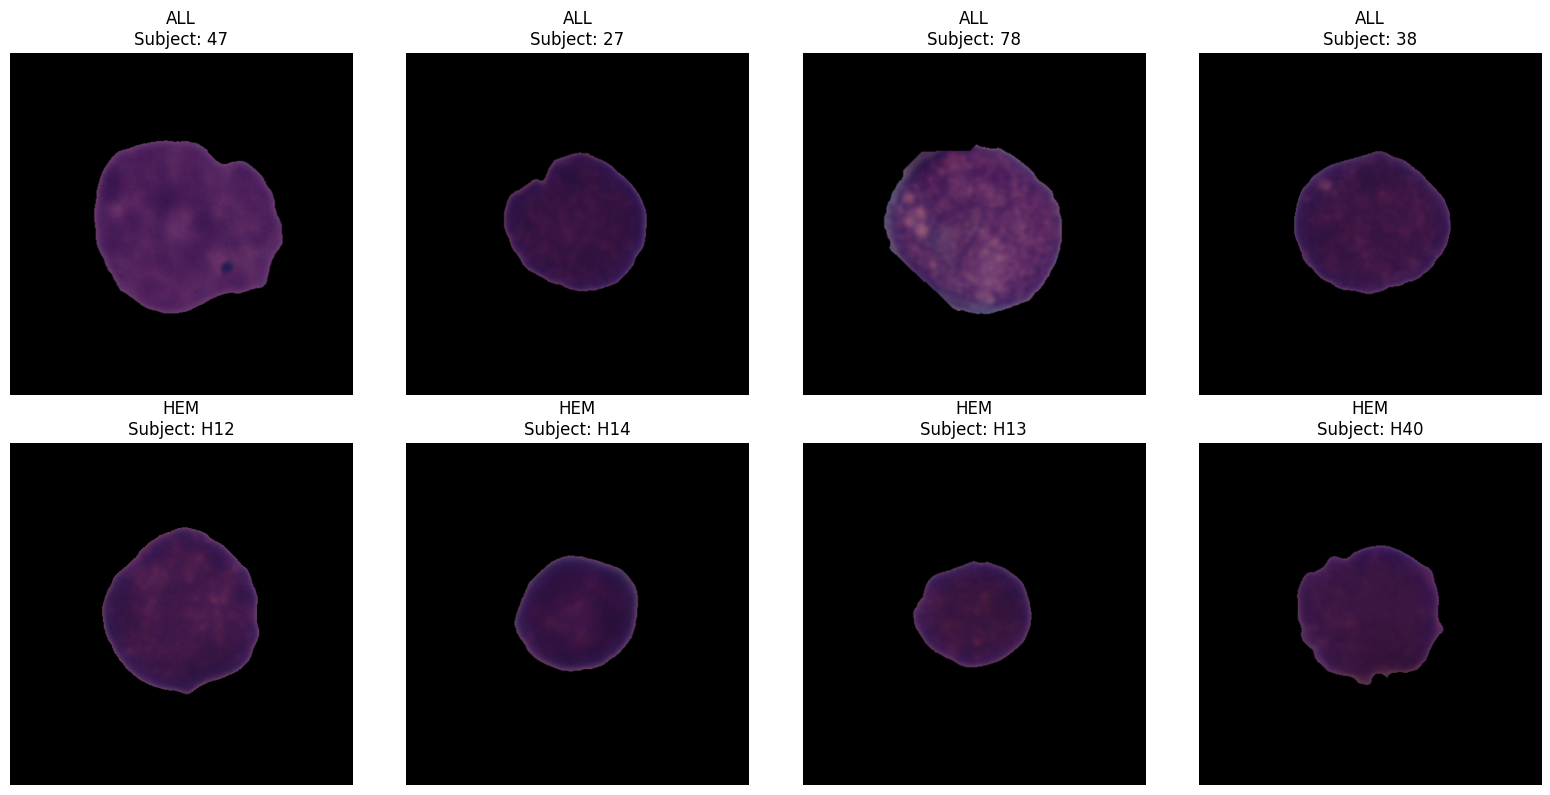

In [ ]:
def show_random_images(df: pd.DataFrame, rows_per_class: int = 4):
    fig, axes = plt.subplots(len(CLASS_NAMES), rows_per_class, figsize=(4 * rows_per_class, 4 * len(CLASS_NAMES)))
    axes = np.array(axes).reshape(len(CLASS_NAMES), rows_per_class)

    for row_idx, class_name in enumerate(CLASS_NAMES):
        class_df = df[df['label_name'] == class_name]
        samples = class_df.sample(min(rows_per_class, len(class_df)), random_state=SEED)

        for col_idx in range(rows_per_class):
            ax = axes[row_idx, col_idx]
            ax.axis('off')

            if col_idx < len(samples):
                sample = samples.iloc[col_idx]
                image = Image.open(sample['filepath']).convert('RGB')
                ax.imshow(image)
                ax.set_title(f"{class_name}\nSubject: {sample['subject_id']}")

    plt.tight_layout()
    plt.show()

show_random_images(metadata, rows_per_class=4)

## 5. Train / Validation / Test Split

A patient-wise stratified split is used when possible. This is preferable for medical imaging because it reduces leakage between training and evaluation data.

In [ ]:
def stratified_subject_split(
    df: pd.DataFrame,
    train_ratio: float = TRAIN_RATIO,
    val_ratio: float = VAL_RATIO,
    test_ratio: float = TEST_RATIO,
    seed: int = SEED,
):
    subject_df = (
        df.groupby('subject_id')['label_name']
        .agg(lambda x: x.mode().iloc[0])
        .reset_index()
    )

    use_subject_split = subject_df['subject_id'].nunique() < len(df)
    enough_groups = subject_df['label_name'].value_counts().min() >= 2 if subject_df['label_name'].nunique() > 1 else False

    if use_subject_split and enough_groups:
        trainval_subjects, test_subjects = train_test_split(
            subject_df,
            test_size=test_ratio,
            stratify=subject_df['label_name'],
            random_state=seed,
        )

        val_relative = val_ratio / (train_ratio + val_ratio)
        train_subjects, val_subjects = train_test_split(
            trainval_subjects,
            test_size=val_relative,
            stratify=trainval_subjects['label_name'],
            random_state=seed,
        )

        train_ids = set(train_subjects['subject_id'])
        val_ids = set(val_subjects['subject_id'])
        test_ids = set(test_subjects['subject_id'])

        train_df = df[df['subject_id'].isin(train_ids)].reset_index(drop=True)
        val_df = df[df['subject_id'].isin(val_ids)].reset_index(drop=True)
        test_df = df[df['subject_id'].isin(test_ids)].reset_index(drop=True)
        split_strategy = 'patient-wise stratified split'
    else:
        temp_df, test_df = train_test_split(
            df,
            test_size=test_ratio,
            stratify=df['label_name'],
            random_state=seed,
        )

        val_relative = val_ratio / (train_ratio + val_ratio)
        train_df, val_df = train_test_split(
            temp_df,
            test_size=val_relative,
            stratify=temp_df['label_name'],
            random_state=seed,
        )

        train_df = train_df.reset_index(drop=True)
        val_df = val_df.reset_index(drop=True)
        test_df = test_df.reset_index(drop=True)
        split_strategy = 'image-level stratified split (fallback)'

    return train_df, val_df, test_df, split_strategy

train_df, val_df, test_df, split_strategy = stratified_subject_split(metadata)

print("Split strategy:", split_strategy)

for name, split_df in [('Train', train_df), ('Validation', val_df), ('Test', test_df)]:
    print(f"\n{name} split")
    print(f"  images   : {len(split_df):,}")
    print(f"  subjects : {split_df['subject_id'].nunique():,}")
    print(split_df['label_name'].value_counts())

train_df.to_csv(TABLE_DIR / "train_split.csv", index=False)
val_df.to_csv(TABLE_DIR / "val_split.csv", index=False)
test_df.to_csv(TABLE_DIR / "test_split.csv", index=False)

Split strategy: patient-wise stratified split

Train split
  images   : 6,631
  subjects : 51
label_name
ALL    4632
HEM    1999
Name: count, dtype: int64

Validation split
  images   : 2,057
  subjects : 11
label_name
ALL    1345
HEM     712
Name: count, dtype: int64

Test split
  images   : 1,973
  subjects : 11
label_name
ALL    1295
HEM     678
Name: count, dtype: int64


## 6. Data Preprocessing and Augmentation

In [ ]:
# Data augmentation for custom CNN training
train_transform_custom = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
])

eval_transform_custom = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
])

# ImageNet normalization is required for pretrained ResNet18
train_transform_resnet = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(RESNET_IMAGE_SIZE, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.10, contrast=0.10, saturation=0.10),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform_resnet = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(RESNET_IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

## 7. PyTorch Dataset and DataLoaders

In [ ]:
# Custom dataset class that reads image paths and labels from the metadata table
class LeukemiaDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(row['filepath']).convert('RGB')
        if self.transform is not None:
            image = self.transform(image)
        label = int(row['label_id'])
        return image, label

train_dataset_custom = LeukemiaDataset(train_df, transform=train_transform_custom)
val_dataset_custom = LeukemiaDataset(val_df, transform=eval_transform_custom)
test_dataset_custom = LeukemiaDataset(test_df, transform=eval_transform_custom)

train_counts = train_df['label_id'].value_counts().sort_index().reindex(range(len(CLASS_NAMES)), fill_value=0)
class_weights = len(train_df) / (len(CLASS_NAMES) * train_counts.values) # Compute class weights for weighted cross-entropy loss
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32, device=device)

print("Training class counts :", train_counts.to_dict())
print("Loss class weights    :", dict(zip(CLASS_NAMES, class_weights.round(4))))

loader_kwargs_custom = {
    'batch_size': BATCH_SIZE,
    'num_workers': NUM_WORKERS,
    'pin_memory': torch.cuda.is_available(),
}

train_loader_custom = DataLoader(train_dataset_custom, shuffle=True, **loader_kwargs_custom)
val_loader_custom = DataLoader(val_dataset_custom, shuffle=False, **loader_kwargs_custom)
test_loader_custom = DataLoader(test_dataset_custom, shuffle=False, **loader_kwargs_custom)

print(f"Custom CNN batches -> train: {len(train_loader_custom)}, val: {len(val_loader_custom)}, test: {len(test_loader_custom)}")

Training class counts : {0: 4632, 1: 1999}
Loss class weights    : {'ALL': np.float64(0.7158), 'HEM': np.float64(1.6586)}
Custom CNN batches -> train: 829, val: 258, test: 247


In [ ]:
train_dataset_resnet = LeukemiaDataset(train_df, transform=train_transform_resnet)
val_dataset_resnet = LeukemiaDataset(val_df, transform=eval_transform_resnet)
test_dataset_resnet = LeukemiaDataset(test_df, transform=eval_transform_resnet)

train_labels_resnet = train_df['label_id'].values
class_sample_counts = np.bincount(train_labels_resnet, minlength=len(CLASS_NAMES))
class_sample_weights = 1.0 / class_sample_counts
sample_weights = class_sample_weights[train_labels_resnet]
sample_weights = torch.DoubleTensor(sample_weights)

# Use weighted sampling so minority-class examples appear more often during ResNet training
resnet_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

print("ResNet training class counts:", dict(zip(CLASS_NAMES, class_sample_counts)))
print("Per-class sampling weights  :", dict(zip(CLASS_NAMES, class_sample_weights.round(6))))

loader_kwargs_resnet = {
    'batch_size': RESNET_BATCH_SIZE,
    'num_workers': NUM_WORKERS,
    'pin_memory': torch.cuda.is_available(),
}

train_loader_resnet = DataLoader(
    train_dataset_resnet,
    sampler=resnet_sampler,
    shuffle=False,
    **loader_kwargs_resnet
)

val_loader_resnet = DataLoader(
    val_dataset_resnet,
    shuffle=False,
    **loader_kwargs_resnet
)

test_loader_resnet = DataLoader(
    test_dataset_resnet,
    shuffle=False,
    **loader_kwargs_resnet
)

print(f"ResNet18 batches -> train: {len(train_loader_resnet)}, val: {len(val_loader_resnet)}, test: {len(test_loader_resnet)}")

ResNet training class counts: {'ALL': np.int64(4632), 'HEM': np.int64(1999)}
Per-class sampling weights  : {'ALL': np.float64(0.000216), 'HEM': np.float64(0.0005)}
ResNet18 batches -> train: 415, val: 129, test: 124


## 8. Define Custom CNN Architecture
Two custom CNN variants are tested:
1. **Baseline** without BatchNorm/Dropout
2. **Regularized** with BatchNorm and Dropout

In [ ]:
# Reusable convolution block with optional BatchNorm and Dropout
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, use_batchnorm=False, dropout_p=0.0):
        super().__init__()
        layers = [nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)]
        if use_batchnorm:
            layers.append(nn.BatchNorm2d(out_channels))
        layers.extend([
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        ])
        if dropout_p > 0:
            layers.append(nn.Dropout2d(dropout_p))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

# Custom CNN model used for baseline and regularized experiments
class CustomCNN(nn.Module):
    def __init__(self, num_classes=2, use_batchnorm=False, dropout_p=0.0):
        super().__init__()
        feature_dropout = dropout_p / 2 if dropout_p > 0 else 0.0

        self.features = nn.Sequential(
            ConvBlock(3, 32, use_batchnorm=use_batchnorm, dropout_p=feature_dropout),
            ConvBlock(32, 64, use_batchnorm=use_batchnorm, dropout_p=feature_dropout),
            ConvBlock(64, 128, use_batchnorm=use_batchnorm, dropout_p=feature_dropout),
            ConvBlock(128, 256, use_batchnorm=use_batchnorm, dropout_p=feature_dropout),
        )

        self.avg_pool = nn.AdaptiveAvgPool2d((4, 4))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_p),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avg_pool(x)
        x = self.classifier(x)
        return x

def count_trainable_parameters(model: nn.Module):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def show_model_summary(model, image_size):
    print(model)
    print(f"\nTrainable parameters: {count_trainable_parameters(model):,}")
    try:
        from torchinfo import summary
        display(summary(
            model,
            input_size=(1, 3, image_size, image_size),
            depth=3,
            col_names=['input_size', 'output_size', 'num_params', 'trainable'],
            verbose=0,
        ))
    except Exception as exc:
        print("\nOptional detailed summary unavailable.")
        print("Reason:", exc)

baseline_model_preview = CustomCNN(num_classes=len(CLASS_NAMES), use_batchnorm=False, dropout_p=0.0).to(device)
regularized_model_preview = CustomCNN(num_classes=len(CLASS_NAMES), use_batchnorm=True, dropout_p=0.30).to(device)

print("BASELINE MODEL SUMMARY")
show_model_summary(baseline_model_preview, IMAGE_SIZE)

print("\n" + "=" * 80 + "\n")
print("REGULARIZED MODEL SUMMARY")
show_model_summary(regularized_model_preview, IMAGE_SIZE)

del baseline_model_preview, regularized_model_preview
if torch.cuda.is_available():
    torch.cuda.empty_cache()

BASELINE MODEL SUMMARY
CustomCNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (2): ConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (3): ConvBlock(
      (block): Sequential(
        (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)


## 9. ResNet18 Transfer Learning Model
ResNet18 is included as an additional comparison model.

In [ ]:
# Replace the final ResNet18 classifier for binary classification
def build_resnet18_model(num_classes=len(CLASS_NAMES), pretrained=True):
    weights = ResNet18_Weights.DEFAULT if pretrained else None
    model = resnet18(weights=weights)

    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.30),
        nn.Linear(in_features, num_classes)
    )
    return model.to(device)

def set_resnet18_trainable_layers(model, mode="head"):
    for param in model.parameters():
        param.requires_grad = False

    if mode == "head":
        for param in model.fc.parameters():
            param.requires_grad = True
    elif mode == "layer4+head":
        for param in model.layer4.parameters():
            param.requires_grad = True
        for param in model.fc.parameters():
            param.requires_grad = True
    elif mode == "all":
        for param in model.parameters():
            param.requires_grad = True
    else:
        raise ValueError("mode must be 'head', 'layer4+head', or 'all'")

resnet_preview = build_resnet18_model(pretrained=True)
print("RESNET18 MODEL SUMMARY")
show_model_summary(resnet_preview, RESNET_IMAGE_SIZE)

del resnet_preview
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 183MB/s]


RESNET18 MODEL SUMMARY
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu)

## 10. Training and Evaluation Functions

In [ ]:
# Run one full epoch of training or validation
def run_epoch(model, loader, criterion, optimizer=None):
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    total_loss = 0.0
    all_labels = []
    all_preds = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):
            outputs = model(images)
            loss = criterion(outputs, labels)

            if is_training:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)

        all_labels.extend(labels.detach().cpu().numpy().tolist())
        all_preds.extend(preds.detach().cpu().numpy().tolist())

    avg_loss = total_loss / len(loader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average='macro')

    return avg_loss, accuracy, macro_f1, np.array(all_labels), np.array(all_preds)

def collect_predictions(model, loader):
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = outputs.argmax(dim=1)

            all_labels.extend(labels.cpu().numpy().tolist())
            all_preds.extend(preds.cpu().numpy().tolist())
            all_probs.extend(probs.cpu().numpy().tolist())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

def evaluate_model(model, loader, class_names, save_prefix=None):
    y_true, y_pred, y_prob = collect_predictions(model, loader)

    accuracy = accuracy_score(y_true, y_pred)
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )

    report_dict = classification_report(
        y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0
    )
    report_df = pd.DataFrame(report_dict).T

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, values_format='d', colorbar=False)
    ax.set_title('Confusion Matrix')
    plt.tight_layout()

    if save_prefix is not None:
        plt.savefig(PLOT_DIR / f"{save_prefix}_confusion_matrix.png", dpi=200, bbox_inches='tight')
    plt.show()

    return {
        'accuracy': accuracy,
        'macro_precision': macro_p,
        'macro_recall': macro_r,
        'macro_f1': macro_f1,
        'weighted_precision': weighted_p,
        'weighted_recall': weighted_r,
        'weighted_f1': weighted_f1,
        'report_df': report_df,
        'y_true': y_true,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'confusion_matrix': cm,
    }

def fit_experiment(config, train_loader, val_loader):
    model = CustomCNN(
        num_classes=len(CLASS_NAMES),
        use_batchnorm=config['use_batchnorm'],
        dropout_p=config['dropout_p'],
    ).to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=2,
    )

    history = {
        'epoch': [],
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': [],
        'train_f1': [],
        'val_f1': [],
        'lr': [],
    }

    best_val_f1 = -np.inf
    best_epoch = 0
    best_state = None
    best_weights_path = MODEL_DIR / f"{config['name']}_best.pth"

    patience = 5
    patience_counter = 0

    for epoch in range(1, EPOCHS + 1):
        train_loss, train_acc, train_f1, _, _ = run_epoch(model, train_loader, criterion, optimizer=optimizer)
        val_loss, val_acc, val_f1, _, _ = run_epoch(model, val_loader, criterion, optimizer=None)

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        history['epoch'].append(epoch)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)
        history['lr'].append(current_lr)

        print(
            f"[{config['name']}] epoch {epoch:02d}/{EPOCHS} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} train_f1={train_f1:.4f} | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_f1={val_f1:.4f} | "
            f"lr={current_lr:.6f}"
        )

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch
            best_state = deepcopy(model.state_dict())

            torch.save({
                'model_state_dict': best_state,
                'class_names': CLASS_NAMES,
                'config': config,
                'image_size': IMAGE_SIZE,
            }, best_weights_path)

            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping for {config['name']} at epoch {epoch}.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return {
        'model': model,
        'history': pd.DataFrame(history),
        'best_val_f1': best_val_f1,
        'best_epoch': best_epoch,
        'weights_path': str(best_weights_path),
        'config': config,
    }

def fit_resnet18_transfer(config, train_loader, val_loader):
    model = build_resnet18_model(
        num_classes=len(CLASS_NAMES),
        pretrained=config.get('pretrained', True)
    )

    criterion = nn.CrossEntropyLoss()

    history = {
        'epoch': [],
        'stage': [],
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': [],
        'train_f1': [],
        'val_f1': [],
        'lr': [],
    }

    best_val_f1 = -np.inf
    best_epoch = 0
    best_state = None
    best_weights_path = MODEL_DIR / f"{config['name']}_best.pth"

    total_epochs = RESNET_HEAD_EPOCHS + RESNET_FINETUNE_EPOCHS
    global_epoch = 0

    stages = [
        {
            'stage_name': 'head_only',
            'train_mode': 'head',
            'epochs': RESNET_HEAD_EPOCHS,
            'patience': 2,
            'make_optimizer': lambda m: optim.AdamW(
                m.fc.parameters(),
                lr=RESNET_HEAD_LR,
                weight_decay=RESNET_WEIGHT_DECAY,
            ),
        },
        {
            'stage_name': 'layer4_plus_head',
            'train_mode': 'layer4+head',
            'epochs': RESNET_FINETUNE_EPOCHS,
            'patience': 3,
            'make_optimizer': lambda m: optim.AdamW(
                [
                    {'params': m.layer4.parameters(), 'lr': RESNET_BACKBONE_LR},
                    {'params': m.fc.parameters(), 'lr': RESNET_FINETUNE_HEAD_LR},
                ],
                weight_decay=RESNET_WEIGHT_DECAY,
            ),
        },
    ]

    for stage in stages:
        set_resnet18_trainable_layers(model, mode=stage['train_mode'])

        optimizer = stage['make_optimizer'](model)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.5,
            patience=1,
        )

        patience_counter = 0

        for _ in range(stage['epochs']):
            global_epoch += 1

            train_loss, train_acc, train_f1, _, _ = run_epoch(model, train_loader, criterion, optimizer=optimizer)
            val_loss, val_acc, val_f1, _, _ = run_epoch(model, val_loader, criterion, optimizer=None)

            scheduler.step(val_loss)
            current_lr = max(group['lr'] for group in optimizer.param_groups)

            history['epoch'].append(global_epoch)
            history['stage'].append(stage['stage_name'])
            history['train_loss'].append(train_loss)
            history['val_loss'].append(val_loss)
            history['train_acc'].append(train_acc)
            history['val_acc'].append(val_acc)
            history['train_f1'].append(train_f1)
            history['val_f1'].append(val_f1)
            history['lr'].append(current_lr)

            print(
                f"[{config['name']}] stage={stage['stage_name']} "
                f"epoch {global_epoch:02d}/{total_epochs} | "
                f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} train_f1={train_f1:.4f} | "
                f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_f1={val_f1:.4f} | "
                f"lr={current_lr:.6f}"
            )

            # Save the model checkpoint with the best validation macro F1-score
            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                best_epoch = global_epoch
                best_state = deepcopy(model.state_dict())

                torch.save({
                    'model_state_dict': best_state,
                    'class_names': CLASS_NAMES,
                    'config': config,
                    'image_size': RESNET_IMAGE_SIZE,
                }, best_weights_path)

                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= stage['patience']:
                    print(f"Early stopping in stage '{stage['stage_name']}' at epoch {global_epoch}.")
                    break

    if best_state is not None:
        model.load_state_dict(best_state)

    return {
        'model': model,
        'history': pd.DataFrame(history),
        'best_val_f1': best_val_f1,
        'best_epoch': best_epoch,
        'weights_path': str(best_weights_path),
        'config': config,
    }

def plot_training_histories(experiment_outputs):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    for name, output in experiment_outputs.items():
        hist = output['history']
        x = range(1, len(hist['train_loss']) + 1)

        axes[0].plot(x, hist['train_loss'], label=f'{name} train')
        axes[0].plot(x, hist['val_loss'], linestyle='--', label=f'{name} val')

        axes[1].plot(x, hist['train_acc'], label=f'{name} train')
        axes[1].plot(x, hist['val_acc'], linestyle='--', label=f'{name} val')

    axes[0].set_title('Training and Validation Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend(fontsize=8)

    axes[1].set_title('Training and Validation Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(PLOT_DIR / "training_curves_comparison.png", dpi=200, bbox_inches='tight')
    plt.show()

## 11. Train Models
We train:
- baseline custom CNN
- regularized custom CNN
- ResNet18 transfer learning

In [ ]:
config_baseline = {
    'name': 'baseline_no_bn_no_dropout',
    'model_family': 'CustomCNN',
    'use_batchnorm': False,
    'dropout_p': 0.0,
    'pretrained': False,
    'input_size': IMAGE_SIZE,
    'description': 'Custom CNN without BatchNorm or Dropout',
}

config_regularized = {
    'name': 'regularized_bn_dropout',
    'model_family': 'CustomCNN',
    'use_batchnorm': True,
    'dropout_p': 0.30,
    'pretrained': False,
    'input_size': IMAGE_SIZE,
    'description': 'Custom CNN with BatchNorm and Dropout regularization',
}

config_resnet18 = {
    'name': 'resnet18_transfer_sampler',
    'model_family': 'ResNet18',
    'pretrained': True,
    'input_size': RESNET_IMAGE_SIZE,
    'description': 'ImageNet-pretrained ResNet18 with WeightedRandomSampler and layer4 fine-tuning',
}

result_baseline = fit_experiment(config_baseline, train_loader_custom, val_loader_custom)
result_regularized = fit_experiment(config_regularized, train_loader_custom, val_loader_custom)
result_resnet18 = fit_resnet18_transfer(config_resnet18, train_loader_resnet, val_loader_resnet)

[baseline_no_bn_no_dropout] epoch 01/12 | train_loss=0.6013 train_acc=0.6999 train_f1=0.6542 | val_loss=0.4831 val_acc=0.8104 val_f1=0.7961 | lr=0.001000
[baseline_no_bn_no_dropout] epoch 02/12 | train_loss=0.5288 train_acc=0.7747 train_f1=0.7391 | val_loss=0.4414 val_acc=0.8303 val_f1=0.8122 | lr=0.001000
[baseline_no_bn_no_dropout] epoch 03/12 | train_loss=0.5179 train_acc=0.7825 train_f1=0.7460 | val_loss=0.4459 val_acc=0.8192 val_f1=0.8032 | lr=0.001000
[baseline_no_bn_no_dropout] epoch 04/12 | train_loss=0.5159 train_acc=0.7762 train_f1=0.7415 | val_loss=0.4438 val_acc=0.8148 val_f1=0.7998 | lr=0.001000
[baseline_no_bn_no_dropout] epoch 05/12 | train_loss=0.5155 train_acc=0.7824 train_f1=0.7474 | val_loss=0.4099 val_acc=0.8342 val_f1=0.8139 | lr=0.001000
[baseline_no_bn_no_dropout] epoch 06/12 | train_loss=0.5116 train_acc=0.7813 train_f1=0.7472 | val_loss=0.4966 val_acc=0.7846 val_f1=0.7741 | lr=0.001000
[baseline_no_bn_no_dropout] epoch 07/12 | train_loss=0.5122 train_acc=0.7862

## 12. Compare Models and Select the Best Model
Selection is based on the best validation **macro F1-score**.

,experiment,model_family,input_size,pretrained,best_epoch,best_val_acc,best_val_macro_f1,final_train_acc,final_val_acc,final_train_loss,final_val_loss,weights_path
0,resnet18_transfer,ResNet18,224,True,4,0.8576,0.8388,0.8706,0.8012,0.3096,0.4578,/content/outputs_cnmc/models/resnet18_transfer...
1,regularized_bn_dropout,CustomCNN,128,False,5,0.8498,0.8229,0.8320,0.7603,0.4356,0.5084,/content/outputs_cnmc/models/regularized_bn_dr...
2,baseline_no_bn_no_dropout,CustomCNN,128,False,5,0.8342,0.8139,0.7886,0.8269,0.4980,0.4401,/content/outputs_cnmc/models/baseline_no_bn_no...


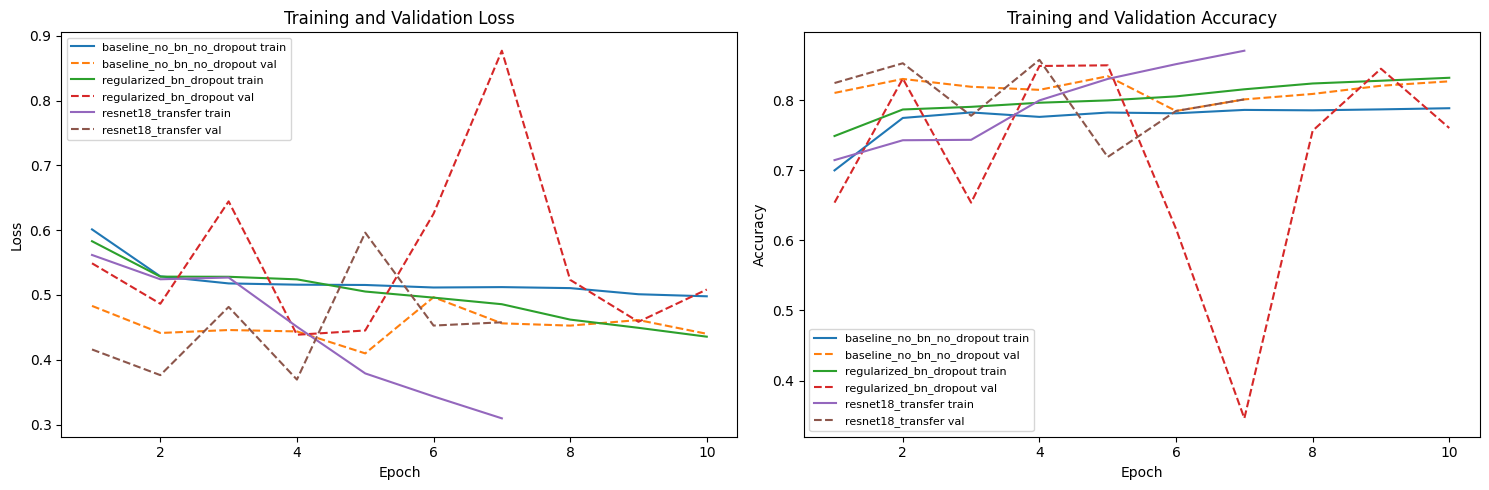

Selected best experiment: resnet18_transfer
Weights file: /content/outputs_cnmc/models/resnet18_transfer_sampler_best.pth
Copied best checkpoint to: /content/outputs_cnmc/models/cnmc_best_model.pth


In [ ]:
experiment_outputs = {
    'baseline_no_bn_no_dropout': result_baseline,
    'regularized_bn_dropout': result_regularized,
    'resnet18_transfer': result_resnet18,
}

experiment_test_loaders = {
    'baseline_no_bn_no_dropout': test_loader_custom,
    'regularized_bn_dropout': test_loader_custom,
    'resnet18_transfer': test_loader_resnet,
}

experiment_test_datasets = {
    'baseline_no_bn_no_dropout': test_dataset_custom,
    'regularized_bn_dropout': test_dataset_custom,
    'resnet18_transfer': test_dataset_resnet,
}

experiment_norms = {
    'baseline_no_bn_no_dropout': ((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    'regularized_bn_dropout': ((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    'resnet18_transfer': (IMAGENET_MEAN, IMAGENET_STD),
}

comparison_rows = []

for name, output in experiment_outputs.items():
    hist = output['history']
    comparison_rows.append({
        'experiment': name,
        'model_family': output['config'].get('model_family', 'Unknown'),
        'input_size': output['config'].get('input_size', IMAGE_SIZE),
        'pretrained': output['config'].get('pretrained', False),
        'best_epoch': int(output['best_epoch']),
        'best_val_acc': float(hist['val_acc'].max()),
        'best_val_macro_f1': float(output['best_val_f1']),
        'final_train_acc': float(hist['train_acc'].iloc[-1]),
        'final_val_acc': float(hist['val_acc'].iloc[-1]),
        'final_train_loss': float(hist['train_loss'].iloc[-1]),
        'final_val_loss': float(hist['val_loss'].iloc[-1]),
        'weights_path': output['weights_path'],
    })

comparison_df = (
    pd.DataFrame(comparison_rows)
    .sort_values(['best_val_macro_f1', 'best_val_acc'], ascending=False)
    .reset_index(drop=True)
)

comparison_df.to_csv(TABLE_DIR / "experiment_comparison_all_models.csv", index=False)
display(comparison_df.round(4))

plot_training_histories(experiment_outputs)

best_experiment_name = comparison_df.iloc[0]['experiment']
best_output = experiment_outputs[best_experiment_name]
best_model = best_output['model']
best_test_loader = experiment_test_loaders[best_experiment_name]

print("Selected best experiment:", best_experiment_name)
print("Weights file:", best_output['weights_path'])

final_model_path = MODEL_DIR / "cnmc_best_model.pth"
shutil.copy2(best_output['weights_path'], final_model_path)
print("Copied best checkpoint to:", final_model_path)

## 13. Evaluate the Best Model on the Test Set

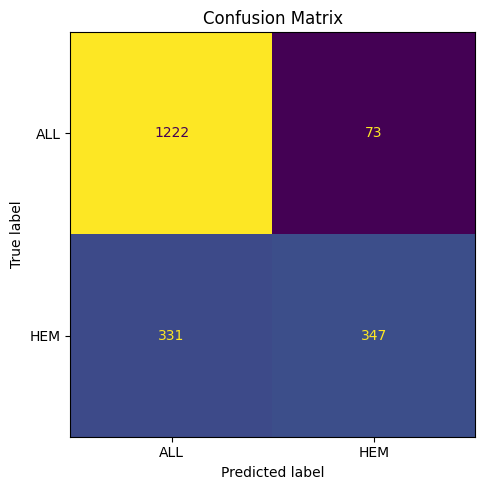

,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,0.7952,0.8065,0.7277,0.7451,0.8004,0.7952,0.7805


In [ ]:
test_results = evaluate_model(
    best_model,
    best_test_loader,
    CLASS_NAMES,
    save_prefix=best_experiment_name,
)

summary_metrics = pd.DataFrame([{
    'accuracy': test_results['accuracy'],
    'macro_precision': test_results['macro_precision'],
    'macro_recall': test_results['macro_recall'],
    'macro_f1': test_results['macro_f1'],
    'weighted_precision': test_results['weighted_precision'],
    'weighted_recall': test_results['weighted_recall'],
    'weighted_f1': test_results['weighted_f1'],
}])

summary_metrics.to_csv(TABLE_DIR / "test_summary_metrics.csv", index=False)
display(summary_metrics.round(4))

In [ ]:
report_df = test_results['report_df'].copy()
report_df.to_csv(TABLE_DIR / "test_classification_report.csv")

display(report_df.round(4))

per_class_df = report_df.loc[CLASS_NAMES, ['precision', 'recall', 'f1-score', 'support']].copy()
per_class_df = per_class_df.sort_values('f1-score', ascending=False)

display(per_class_df.round(4))

best_class = per_class_df.index[0]
worst_class = per_class_df.index[-1]

print(f"Best performing class by F1-score : {best_class}")
print(f"Worst performing class by F1-score: {worst_class}")

,precision,recall,f1-score,support
ALL,0.7869,0.9436,0.8581,1295.0000
HEM,0.8262,0.5118,0.6321,678.0000
accuracy,0.7952,0.7952,0.7952,0.7952
macro avg,0.8065,0.7277,0.7451,1973.0000
weighted avg,0.8004,0.7952,0.7805,1973.0000


,precision,recall,f1-score,support
ALL,0.7869,0.9436,0.8581,1295.0
HEM,0.8262,0.5118,0.6321,678.0


Best performing class by F1-score : ALL
Worst performing class by F1-score: HEM


## 14. Misclassified Examples

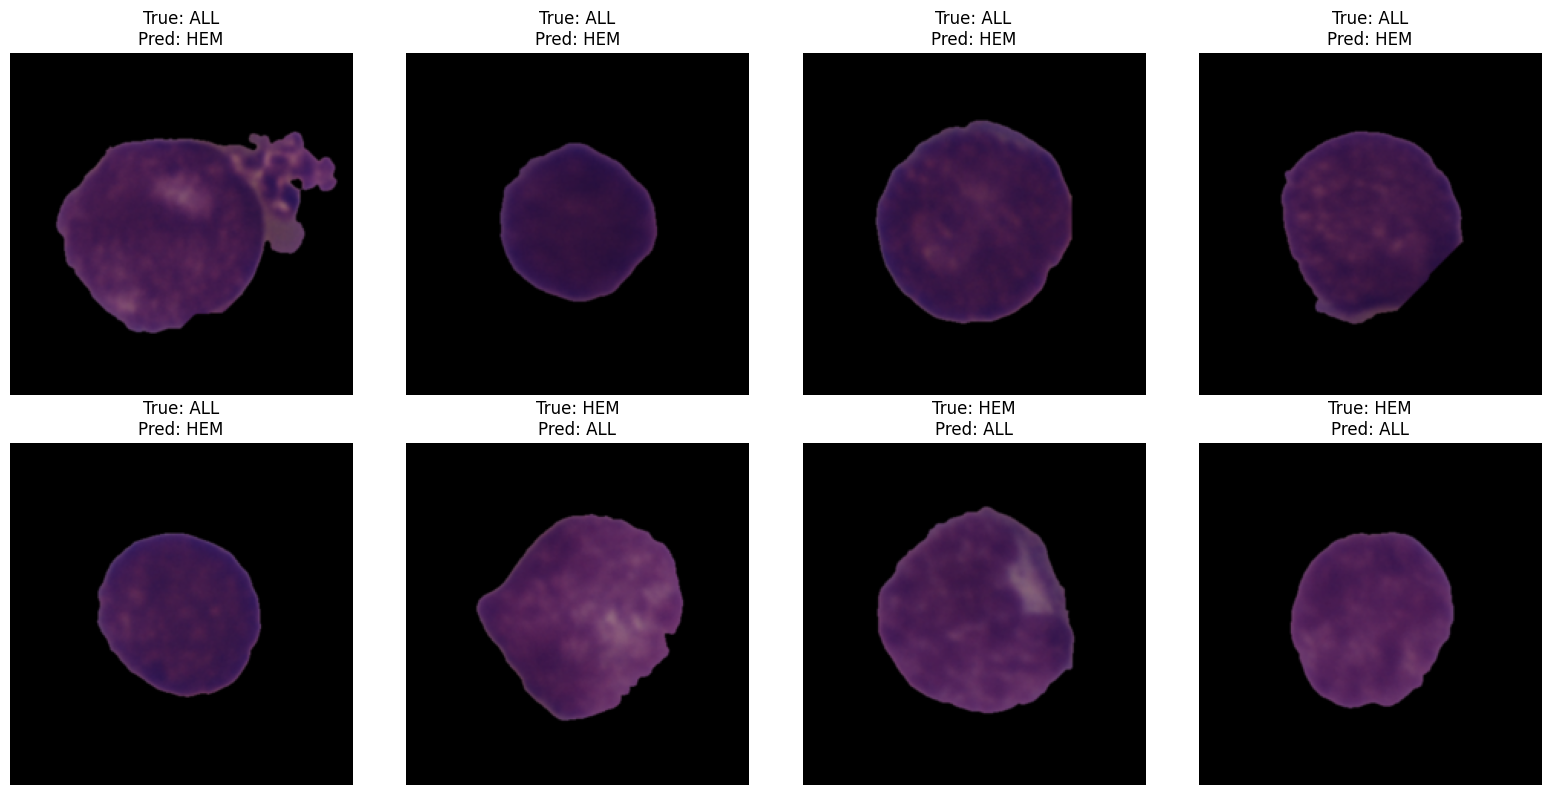

In [ ]:
# Reverse normalization for display
def denormalize_image(tensor_img, mean, std):
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return (tensor_img.cpu() * std + mean).clamp(0, 1)

# Show a few wrongly predicted test images
def show_misclassified_examples(dataset, y_true, y_pred, mean, std, max_examples=8):
    wrong_indices = np.where(y_true != y_pred)[0]

    if len(wrong_indices) == 0:
        print("No misclassified examples were found.")
        return

    wrong_indices = wrong_indices[:max_examples]
    cols = 4
    rows = int(np.ceil(len(wrong_indices) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis('off')

    for ax, idx in zip(axes, wrong_indices):
        image_tensor, _ = dataset[idx]
        image = denormalize_image(image_tensor, mean, std).permute(1, 2, 0).numpy()
        ax.imshow(image)
        ax.set_title(
            f"True: {ID_TO_CLASS[int(y_true[idx])]}\nPred: {ID_TO_CLASS[int(y_pred[idx])]}"
        )

    plt.tight_layout()
    plt.savefig(PLOT_DIR / "misclassified_examples.png", dpi=200, bbox_inches='tight')
    plt.show()

best_dataset = experiment_test_datasets[best_experiment_name]
best_mean, best_std = experiment_norms[best_experiment_name]

show_misclassified_examples(
    best_dataset,
    test_results['y_true'],
    test_results['y_pred'],
    best_mean,
    best_std,
    max_examples=8
)

## 15. ROC Curve
Because this is a binary classification task, ROC-AUC is also reported for the selected best model.

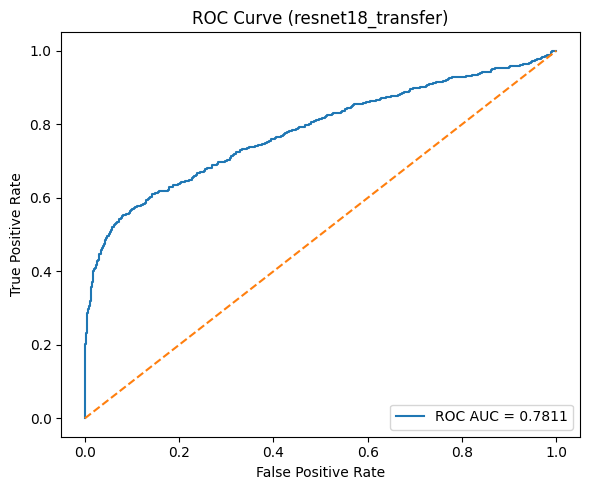

Test ROC-AUC: 0.7811


In [ ]:
if len(CLASS_NAMES) == 2:
    positive_class_id = CLASS_TO_ID['HEM']

    y_true = test_results['y_true']
    y_score = test_results['y_prob'][:, positive_class_id]

    roc_auc = roc_auc_score(y_true, y_score)
    fpr, tpr, _ = roc_curve(y_true, y_score, pos_label=positive_class_id)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve ({best_experiment_name})")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f"{best_experiment_name}_roc_curve.png", dpi=200, bbox_inches='tight')
    plt.show()

    roc_df = pd.DataFrame([{
        'experiment': best_experiment_name,
        'roc_auc': roc_auc
    }])
    roc_df.to_csv(TABLE_DIR / "test_roc_auc.csv", index=False)

    print(f"Test ROC-AUC: {roc_auc:.4f}")

## 16. Final Summary
This section prints a concise summary suitable for the report discussion.

In [ ]:
print("=== Experiment Comparison Summary ===")
for _, row in comparison_df.iterrows():
    print(
        f"{row['experiment']}: "
        f"best_val_macro_f1={row['best_val_macro_f1']:.4f}, "
        f"best_val_acc={row['best_val_acc']:.4f}, "
        f"best_epoch={int(row['best_epoch'])}"
    )

print("\n=== Final Test Summary ===")
print(f"Best selected model         : {best_experiment_name}")
print(f"Test Accuracy              : {test_results['accuracy']:.4f}")
print(f"Test Macro Precision       : {test_results['macro_precision']:.4f}")
print(f"Test Macro Recall          : {test_results['macro_recall']:.4f}")
print(f"Test Macro F1-score        : {test_results['macro_f1']:.4f}")
print(f"Best performing class (F1) : {best_class}")
print(f"Worst performing class (F1): {worst_class}")

=== Experiment Comparison Summary ===
resnet18_transfer: best_val_macro_f1=0.8388, best_val_acc=0.8576, best_epoch=4
regularized_bn_dropout: best_val_macro_f1=0.8229, best_val_acc=0.8498, best_epoch=5
baseline_no_bn_no_dropout: best_val_macro_f1=0.8139, best_val_acc=0.8342, best_epoch=5

=== Final Test Summary ===
Best selected model         : resnet18_transfer
Test Accuracy              : 0.7952
Test Macro Precision       : 0.8065
Test Macro Recall          : 0.7277
Test Macro F1-score        : 0.7451
Best performing class (F1) : ALL
Worst performing class (F1): HEM


## 17. Save All Outputs as a ZIP File
This cell creates a ZIP archive of the outputs directory. In Colab it also triggers a download.

In [ ]:
archive_path = shutil.make_archive("/content/outputs_cnmc", "zip", "/content/outputs_cnmc")
print("Created:", archive_path)

try:
    from google.colab import files
    files.download(archive_path)
except ImportError:
    print("Not running in Colab. Archive saved at:", archive_path)

Created: /content/outputs_cnmc.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 18. Conclusions and Future Work

### Conclusion
- A custom CNN was successfully developed for the C-NMC Leukemia dataset.
- A regularized version with BatchNorm and Dropout was compared against the baseline.
- ResNet18 transfer learning was used as an additional comparison model.
- The final selected model was evaluated on the held-out test set using comprehensive metrics.

### Future Work
- Tune more augmentation and learning rate schedules
- Try focal loss or class-balanced loss for harder minority patterns
- Use cross-validation for more robust model selection
- Explore attention-based or more advanced medical imaging architectures